<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/Gradient_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("mathchi/churn-for-bank-customers")

100%|██████████| 261k/261k [00:00<00:00, 55.4MB/s]

Extracting files...


In [3]:
import pandas as pd
import os

# List the contents of the downloaded path to find the correct CSV file
files_in_path = os.listdir(path)
print(f"Files in the downloaded directory '{path}': {files_in_path}")

# Assuming 'Churn_Modelling.csv' is one of the files in the list, or we need to adjust
# For now, let's assume it might be directly in the path if the previous assumption was just a naming issue.
# If not, further inspection or user input will be needed to identify the correct file.

# Try to find a .csv file in the directory
csv_files = [f for f in files_in_path if f.endswith('.csv')]

if csv_files:
    # Assuming the first CSV file found is the correct one
    actual_csv_filename = csv_files[0]
    csv_file_path = os.path.join(path, actual_csv_filename)
    df = pd.read_csv(csv_file_path)

    print(f"Data loaded successfully from '{actual_csv_filename}'. First 5 rows of the DataFrame:\n{df.head()}")
    print(f"DataFrame shape: {df.shape}")
else:
    print("No CSV files found in the downloaded directory. Please check the dataset contents.")
    df = None # Set df to None or handle as appropriate if no CSV is found

Files in the downloaded directory '/root/.cache/kagglehub/datasets/mathchi/churn-for-bank-customers/versions/1': ['churn.csv']
Data loaded successfully from 'churn.csv'. First 5 rows of the DataFrame:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82    

In [4]:
df.sample(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2562,2563,15646566,Bell,763,France,Female,58,9,187911.55,1,0,1,35825.18,0
4047,4048,15656707,Ma,720,Spain,Male,21,2,123200.78,1,1,1,180712.28,0
8880,8881,15603764,Chang,560,France,Male,49,4,0.00,1,1,1,100075.10,1


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop irrelevant features
df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Identify features (X) and target (y)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(exclude=['object']).columns

# Create a column transformer for one-hot encoding categorical features
# and passing numerical features through
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply the preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset preparation complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Dataset preparation complete.
Shape of X_train: (8000, 13)
Shape of X_test: (2000, 13)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [6]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42)

# Train the model
print("Training Gradient Boosting Classifier...")
gbc.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred = gbc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training Gradient Boosting Classifier...
Training complete.

Model Accuracy: 0.8690

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000


Confusion Matrix:
[[1537   56]
 [ 206  201]]


/tmp/ipykernel_2425/4089997664.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')


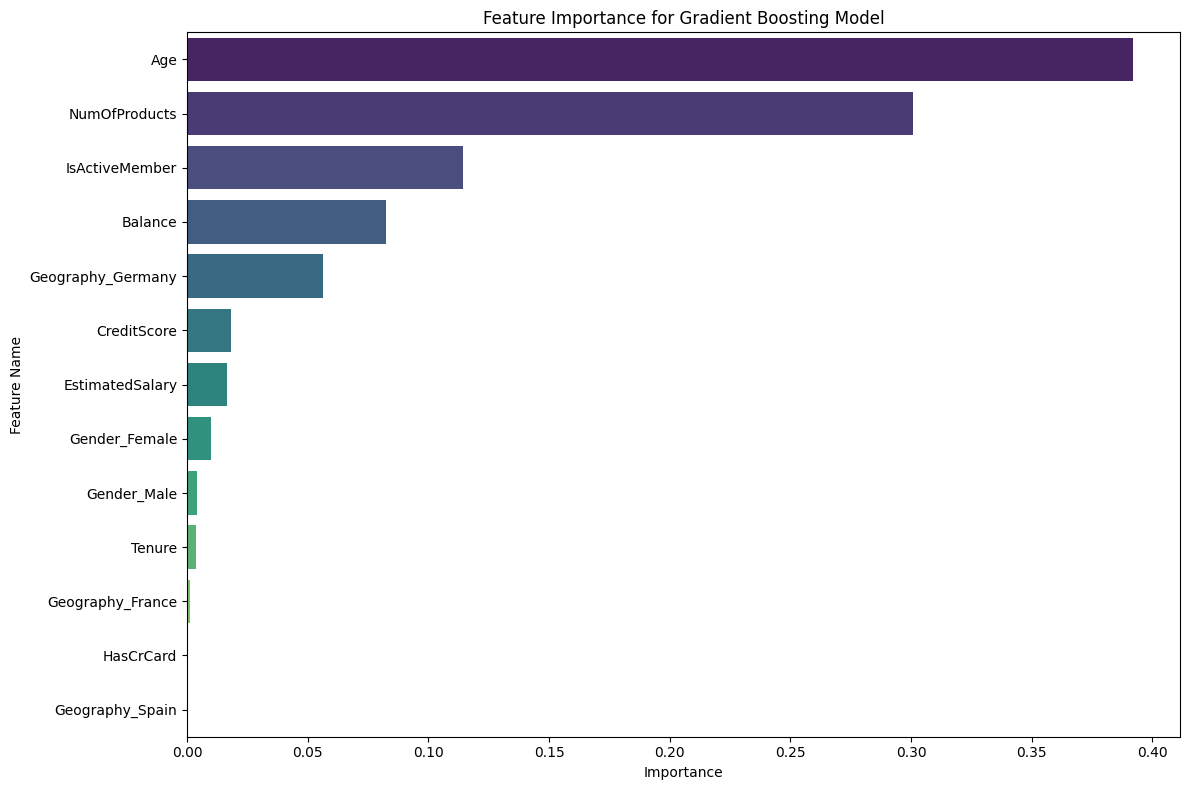

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get feature names after one-hot encoding
# Numerical features
feature_names = list(numerical_features)

# Categorical features after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# Get feature importances from the trained model
importances = gbc.feature_importances_

# Create a Series for easier handling and sorting
feature_importances = pd.Series(importances, index=feature_names)

# Sort the features by importance in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')
plt.title('Feature Importance for Gradient Boosting Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the parameter grid for Gradient Boosting Classifier
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting stages
    'learning_rate': [0.05, 0.1, 0.2],  # Step size shrinkage to prevent overfitting
    'max_depth': [3, 4, 5],  # Maximum depth of the individual regression estimators
    'min_samples_split': [2, 5], # The minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2] # The minimum number of samples required to be at a leaf node
}

# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42)

# Initialize GridSearchCV
# Using 'f1' as a scoring metric is often better for imbalanced datasets
# n_jobs=-1 uses all available processors
grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid,
                           scoring='f1', cv=3, verbose=2, n_jobs=-1)

print("Starting GridSearchCV for Hyperparameter Tuning...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Parameters found: {best_params}")
print(f"Best F1-Score on training data (cross-validation): {best_score:.4f}")

# Get the best model
best_gbc_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned = best_gbc_model.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"\nModel Accuracy with tuned parameters on Test Set: {accuracy_tuned:.4f}")

print("\nClassification Report with tuned parameters:")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix with tuned parameters:")
print(confusion_matrix(y_test, y_pred_tuned))

Starting GridSearchCV for Hyperparameter Tuning...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Hyperparameter tuning complete.

Best Parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-Score on training data (cross-validation): 0.5953

Model Accuracy with tuned parameters on Test Set: 0.8660

Classification Report with tuned parameters:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.85      2000


Confusion Matrix with tuned parameters:
[[1531   62]
 [ 206  201]]


# from the scratch

In [1]:
import kagglehub
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.


In [2]:
import pandas as pd
import os

# List the contents of the downloaded path to find the correct CSV file
files_in_path = os.listdir(path)
print(f"Files in the downloaded directory '{path}': {files_in_path}")

# Assuming the CSV file is named 'winequality-red.csv' or similar
# Let's try to find a .csv file and load the first one we find
csv_files = [f for f in files_in_path if f.endswith('.csv')]

if csv_files:
    actual_csv_filename = csv_files[0]
    csv_file_path = os.path.join(path, actual_csv_filename)
    df = pd.read_csv(csv_file_path)
    print(f"Data loaded successfully from '{actual_csv_filename}'. First 5 rows of the DataFrame:\n{df.head()}")
    print(f"DataFrame shape: {df.shape}")
else:
    print("No CSV files found in the specified directory. Please check the dataset contents.")
    df = None

Files in the downloaded directory '/kaggle/input/red-wine-quality-cortez-et-al-2009': ['winequality-red.csv']
Data loaded successfully from 'winequality-red.csv'. First 5 rows of the DataFrame:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  6

In [3]:
df.sample(4)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
442,15.6,0.685,0.76,3.7,0.100,6.0,43.0,1.00320,2.95,0.68,11.2,7
1525,6.7,0.480,0.08,2.1,0.064,18.0,34.0,0.99552,3.33,0.64,9.7,5
1426,7.7,0.230,0.37,1.8,0.046,23.0,60.0,0.99710,3.41,0.71,12.1,6
653,9.4,0.330,0.59,2.8,0.079,9.0,30.0,0.99760,3.12,0.54,12.0,6


In [4]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [5]:
df['f0'] = df['quality'].mean()
print(f"Mean of 'quality' column: {df['quality'].mean():.2f}")
print("First 5 rows of DataFrame with new 'f0' column:")
print(df.head())

Mean of 'quality' column: 5.64
First 5 rows of DataFrame with new 'f0' column:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alco

In [7]:
df['rs1'] = df['quality'] - df['f0']
print("First 5 rows of DataFrame with new 'rs1' (residual) column:")
print(df.head())

First 5 rows of DataFrame with new 'rs1' (residual) column:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality       

In [8]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Define features (X) by excluding specified columns
X = df.drop(columns=['quality', 'f0', 'rs1'])
# Define target (y) as 'rs1'
y = df['rs1']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Train the model
print("Training Gradient Boosting Regressor...")
gbr.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_rs1 = gbr.predict(X_test)

# Add the predictions as a new column to a DataFrame (or print directly)
df_predictions = pd.DataFrame({'Actual_rs1': y_test, 'Predicted_rs1': y_pred_rs1})

print("\nFirst 5 predictions:")
print(df_predictions.head())

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_rs1)
r2 = r2_score(y_test, y_pred_rs1)

print(f"\nMean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Training Gradient Boosting Regressor...
Training complete.

First 5 predictions:
      Actual_rs1  Predicted_rs1
803     0.363977      -0.294376
124    -0.636023      -0.613490
350     0.363977      -0.357714
682    -0.636023      -0.351339
1326    0.363977       0.142857

Mean Squared Error: 0.3630
R-squared: 0.4446


Training Decision Tree Regressor...
Training complete.


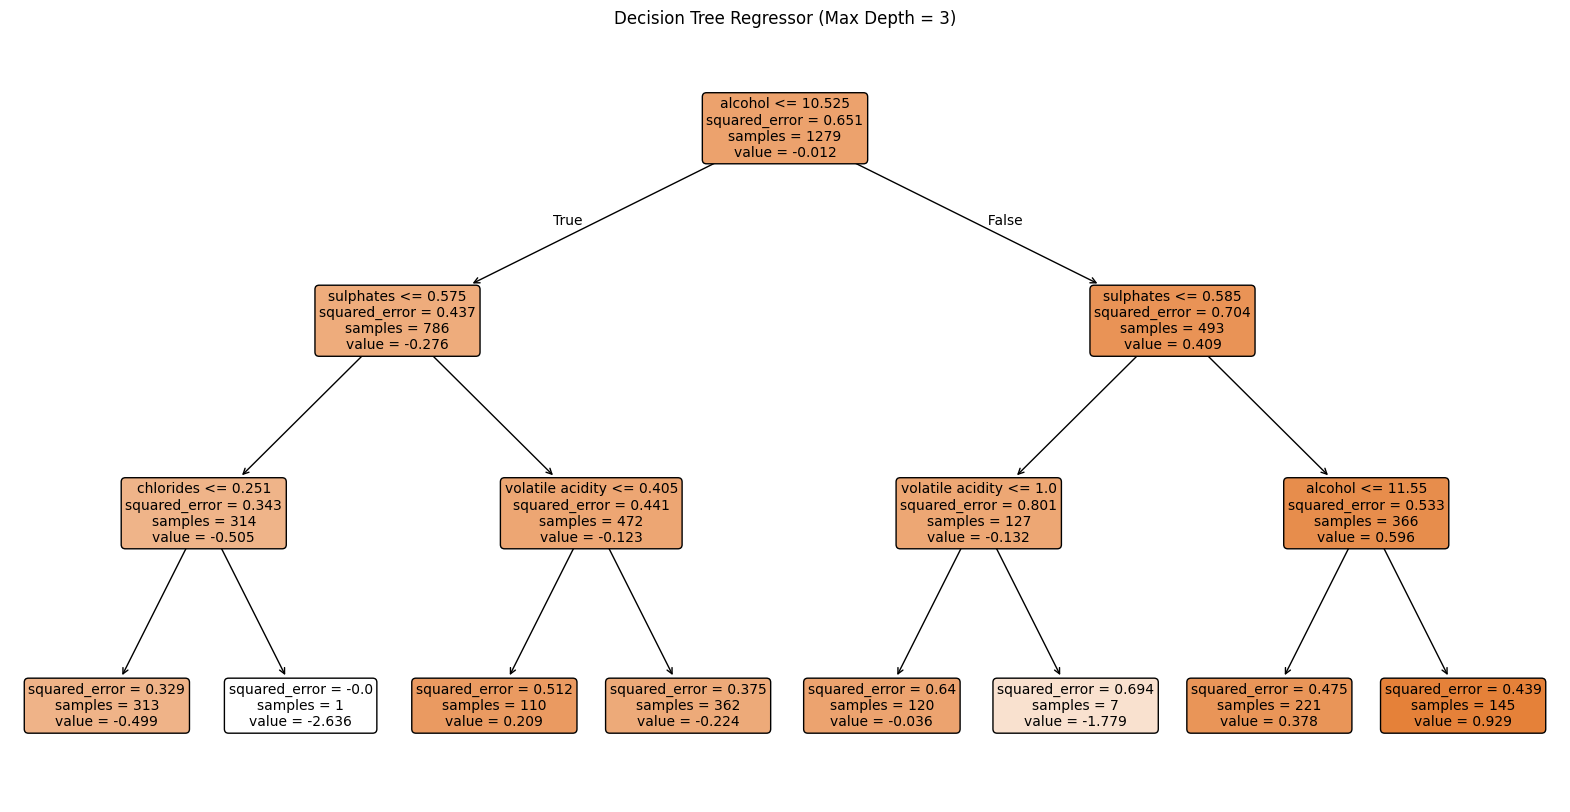


Decision Tree Regressor Evaluation (Max Depth = 3):
Mean Squared Error: 0.4652
R-squared: 0.2882


In [9]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Define features (X) by excluding specified columns
X_dt = df.drop(columns=['quality', 'f0', 'rs1'])
# Define target (y) as 'rs1'
y_dt = df['rs1']

# Split the data into training and testing sets (using the same split as before for consistency)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)

# Initialize a Decision Tree Regressor
# Limiting max_depth for better visualization. You can adjust this value.
dtr = DecisionTreeRegressor(max_depth=3, random_state=42)

# Train the Decision Tree model
print("Training Decision Tree Regressor...")
dtr.fit(X_train_dt, y_train_dt)
print("Training complete.")

# Get feature names for visualization
feature_names_dt = X_dt.columns.tolist()

# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dtr, feature_names=feature_names_dt, filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Regressor (Max Depth = 3)')
plt.show()

# Optional: Evaluate the Decision Tree
from sklearn.metrics import mean_squared_error, r2_score
y_pred_dt = dtr.predict(X_test_dt)
mse_dt = mean_squared_error(y_test_dt, y_pred_dt)
r2_dt = r2_score(y_test_dt, y_pred_dt)

print(f"\nDecision Tree Regressor Evaluation (Max Depth = 3):")
print(f"Mean Squared Error: {mse_dt:.4f}")
print(f"R-squared: {r2_dt:.4f}")